### Кластеризация

#### Цель работы

Освоить на практике основные приемы работы с самыми распространенными алгоритмами кластеризации.


#### Методические указания

Алгоритмы кластеризации, то есть разбиения точек выборки на пересекающиеся группы по схожести значения признаков, применяются для решения многих практических задач. Самая распространенная их них - это сегментация клиентов. Задача сегментации состоит в том, чтобы выделить среди клиентов организации какие-то заранее не известные группы таким образом, чтобы внутри каждой группы оказались похожие клиенты.

Посмотрим, как работают самые базовые алгоритмы кластеризации на примере как раз такой задачи. Скачаем датасет с данными о нескольких сотнях клиентов торговой компании:


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
# Ссылка на "сырой" файл mall_customers_clustering.csv
url = 'https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML6.1%20clustering/data/mall_customers_clustering.csv'

# Загружаем данные
# index_col=0 используется, так как первый столбец в этом файле — это ID покупателя
df = pd.read_csv(url, index_col=0)

# Выведем первые строки, чтобы убедиться в названиях столбцов
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


В этом наборе данных приведена базовая информация о клиентах, которая может быть полезна для категоризации их потребительского поведения:

Мы специально выбрали набор данных, содержащий небольшое количество столбцов. На этом примере мы еще сможем проследить логику кластеризации, что было бы значительно сложнее в большом количестве измерений.

Для того, чтобы представлять общую форму датасета давайте изобразим его на графике. В датасете четыре значащих признака, но один их них - пол - бинарный, что легко можно изобразить на графике цветом. Выберем еще два признака, которые расположим по осям, например:

<Axes: xlabel='Income', ylabel='Score'>

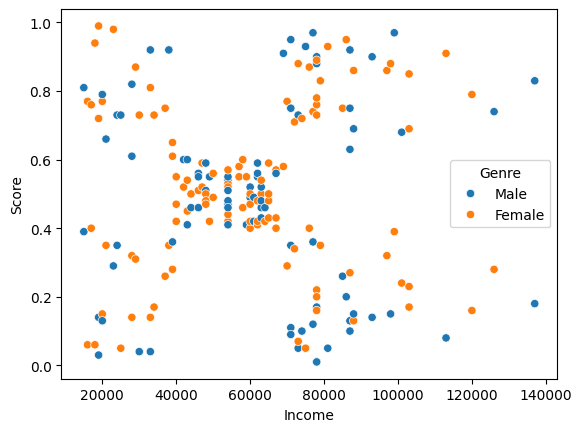

In [9]:
import seaborn as sns
sns.scatterplot(x='Income' , y='Score',data=df , hue='Genre')

Всегда следует помнить, что в реальности данные более многомерны. В данном случае, мы видим только проекцию на плоскость. У нас есть еще одно численное измерение. Попробуйте самостоятельно изобразить датасет в других проекциях и представьте, как он выглядит в трехмерном пространстве.

Для дальнейшей работы нам понадобится произвести минимальную техническую предобработку данных:

In [10]:
x = df.drop(["CustomerID"], axis=1)
X = pd.get_dummies(x
                   )

В данном случае, мы избавились от неинформативного атрибута, и преобразовали категориальный атрибут в численные признаки. Вот как выглядит наш датасет уже в виде матрицы признаков:

In [12]:
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


Теперь мы можем приступать к построению различных алгоритмов кластеризации на этих данных.

##### Кластеризация К-средних

Для начала попробуем самый простой и распространенный алгоритм кластеризации - К-средних. Для его использования нужно импортировать соответствующий класс из пакета cluster библиотеки sklearn:


In [13]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=42).fit(X)

Обратите внимание, что в целом, работа с алгоритмами обучения без учителя в этой библиотеке ничем не отличается от уже известных нам алгоритмов обучения с учителем. Только метод fit() принимает только один аргумент - матрицу признаков X.

Также нужно заметить, что алгоритм К-средних принимает один обязательный аргумент в своем конструкторе - желаемое количество кластеров. Алгоритм К-средних всегда разбивает выборку на заранее заданное количество. Для начала попробуем три кластера. Про выбор количества кластеров поговорим позднее.

Прежде чем оценивать качество работы обученного алгоритма, надо получить информацию о том, какую точку к какому кластеру модель отнесла. Эти данные содержатся в свойстве labels_:

In [14]:
y_kmeans = k_means.labels_

Выведите этот массив и посмотрите, как обозначаются метки кластеров. А мы используем его для визуализации разделения выборки на кластеры:

Объект KMeans сохраняет еще одну полезную для нас информацию, которую можно использовать для визуализации - позиции центров кластеров.

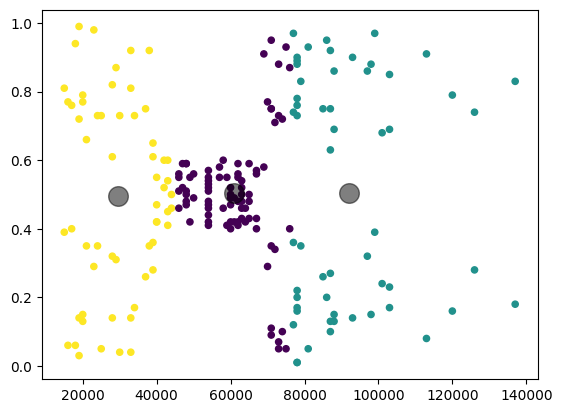

In [17]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

Обратите внимание, какие индексы мы используем для визуализации. Они соответствуют номерам столбцов в матрице признаков. Поэтому если матрица изменилась, либо вы хотите визуализировать другие оси, индексы нужно будет поменять.

Вот как выглядит итоговая визуализация:

Очень просто убедиться, что визуализация построена корректно: центры кластеров соответствуют их очертаниям. В данном случае мы, как и задавали, получили три кластера. Но теперь перед нами встает вопрос, а правильное ли число кластеров мы выбрали? Для того,чтобы принимать решение, какое количество кластеров лучше или хуже, нам нужно воспользоваться метрикой качества. Мы возьмем самую распространенную - WCSS, или инерцию. Она уже рассчитана автоматически и помещена в свойство inertia_

Воспользуемся методом локтя для выбора оптимального количества кластеров. Для этого обучим модель с разным количеством, скажем, от 1 до 10, и для каждого количества выведем значение WCSS на графике:

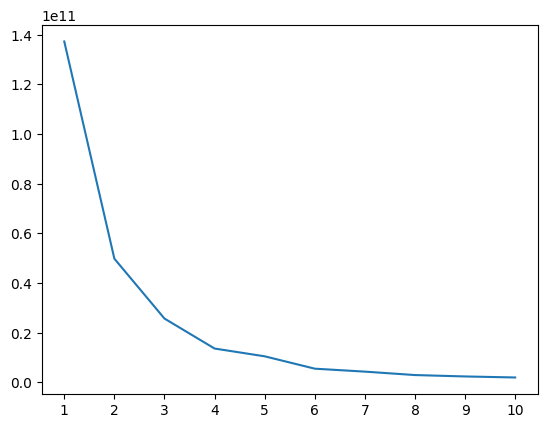

In [18]:
wcss = []
for i in range(1,11):
	k_means = KMeans(n_clusters=i,random_state=42)
	k_means.fit(X)
	wcss.append(k_means.inertia_)
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
_ = plt.show()

Мы видим очень типичную картину: чем больше кластеров, тем меньше значение метрики WSCC. Но в начале она падает очень быстро, а при дальнейшем увеличении количества - начинает все больше выравниваться. Наша задача найти "излом" на этой кривой, то есть такое значение, после которого метрика продолжает падает уже значительно медленнее:

На некоторых кривых такой локоть более выражен, другие - более плавные, в отдельных случаях локтей может быть несколько. Метод локтя - не точная наука, а некоторый примерный ориентир. В данном случае, можно видеть, что 4 кажется неплохим выбором. Давайте построим кластеризацию на 4 кластера:

In [21]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X)

Также изобразим ее на графике. Мы видим очень сходную картину (и она нас должна насторожить):

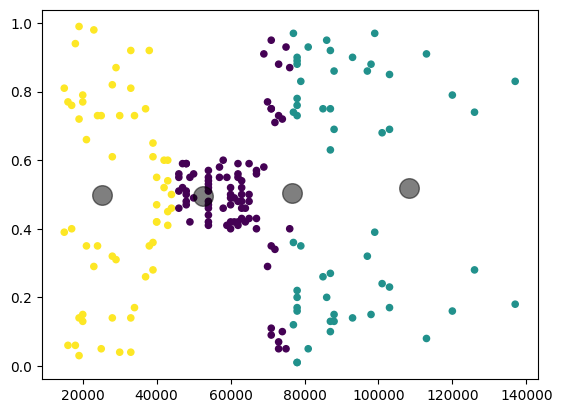

In [24]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

"На глаз" разделение данной выборки на 4 части не кажется оптимальным. Даже с учетом того, что мы видим датасет в проекции, кажется что при другом расположении центров кластеры были бы более компактными. Это странное поведение алгоритма. Давайте проверим его еще раз, значительно увеличив количество кластеров:

In [25]:
k_means = KMeans(n_clusters=8, random_state=42).fit(X)

Мы видим еще более явно странную картину:

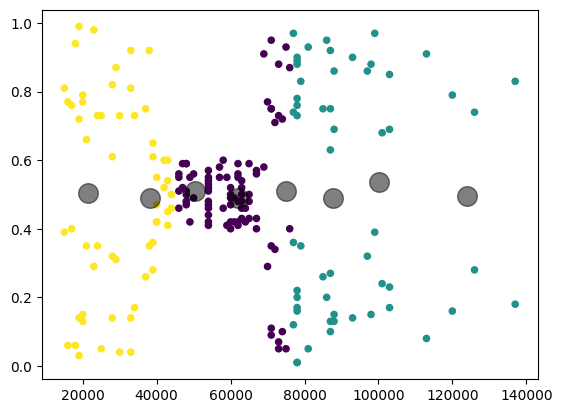

In [26]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

Центры кластеров подозрительно всегда располагаются вдоль одной оси. И это не кажется оптимальным, когда мы смотрим на общее расположение точек. Если вы видите такое поведение, когда странное поведение выражается вдоль определенной оси, это должно вас навести на мысль о том, что что-то не так с масштабом.

И действительно, если мы взглянем на подписи осей, станет очевидным, что горизонтальная ось выражена в десятках тысяч, а вертикальная - в долях единицы. У нас типично ненормализованные данные. Давайте исправим эту ошибку и посмотрим, как это отразится на результатах кластеризации.

##### Нормализация признаков

Алгоритм К-средних, будучи метрическим методом, основывается на вычислении расстояний между точками выборки. Поэтому данные перед началом обучения обязательно надо нормировать. Мы воспользуемся стандартизацией, хотя здесь подошел бы и минимаксный способ.


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405


Обратите внимание, что мы во избежании путаницы сохраняем датасет в новую переменную. Вот как будет выглядеть нормированная матрица признаков:

Визуально при построении распределения ничего не поменялось, вся разница видна только в масштабе осей:

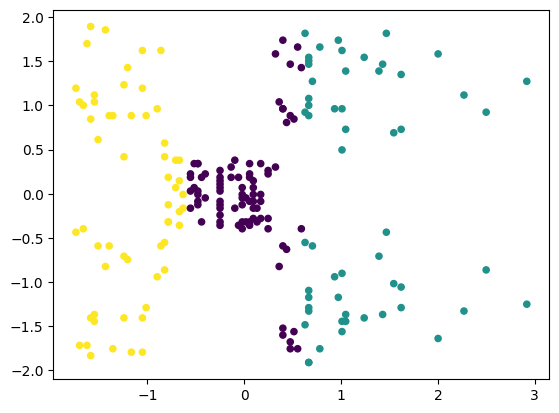

In [41]:
plt.scatter(X_scaled.Income, X_scaled.Score, c=y_kmeans, s=20, cmap='viridis')
# centers = k_means.cluster_centers_
# plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

Теперь давайте повторим наш анализ методом локтя. Для наглядности выведем сразу два графика: по нормализованным данным и по исходной матрице:

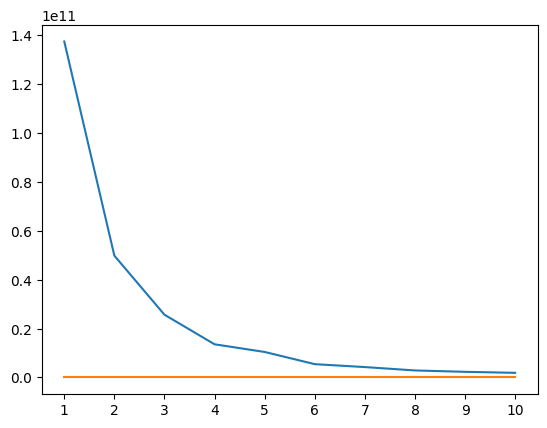

In [42]:
unscaled, scaled = [], []
for i in range(1,11):
	unscaled.append(KMeans(n_clusters=i,random_state=42).fit(X).inertia_)
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_scaled).inertia_)
plt.plot(range(1,11),unscaled)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

Мы видим, что второй график выглядит горизонтальной линией на нулевом уровне:

Но все дело опять же в масштабе. Дело в том, что сумма квадратов расстояний по ненормализованным данным учитывала большой масштаб одного из признаков (именно поэтому он доминировал при кластеризации). Посмотрите на подпись вертикальной оси - метрика WCSS у нас измеряется числом с 11 нулями.

Если вывести только график кластеризации по нормированным данным, все станет понятнее:

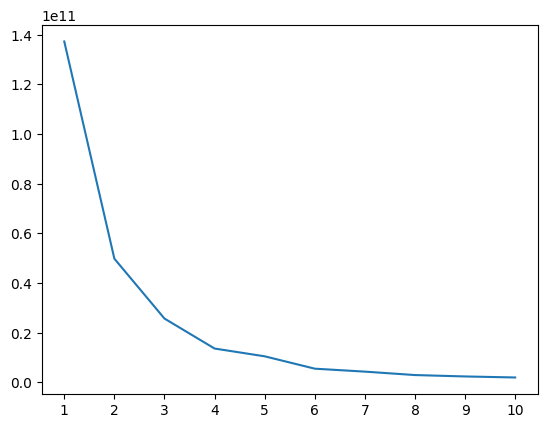

In [43]:
unscaled, scaled = [], []
for i in range(1,11):
	unscaled.append(KMeans(n_clusters=i,random_state=42).fit(X).inertia_)
plt.plot(range(1,11),unscaled)

plt.xticks(range(1,11))
_ = plt.show()

Теперь WCSS измеряется всего в сотнях. Это кстати, значит, что судя только по этой метрике, кластеры получились гораздо компактнее в нормированной матрице. Оно и понятно. По этому графику аналогично можно вывести, что 4 - оптимальное количество кластеров. Повторим обучение модели:

In [39]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X_scaled)

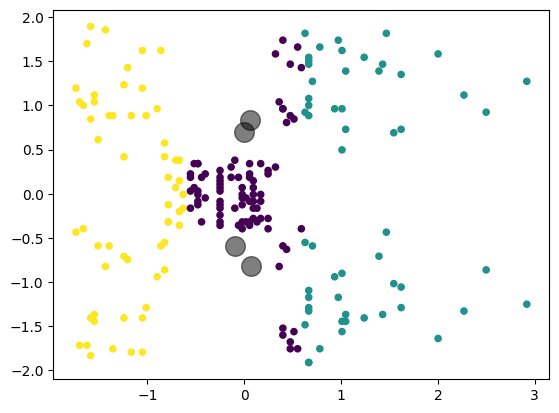

In [44]:
plt.scatter(X_scaled.Income, X_scaled.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

Главное, что центры кластеров уже не выстраиваются в линию параллельно одному из измерений. Однако, кластеры кажутся перемешанными. Это происходит от того, что мы смотрим на датасет в проекции. Поэтому при решении реальных задач не всегда можно опираться на визуализацию, а ориентироваться нужно в первую очередь на метрики.

Но для того, чтобы продемонстрировать то, насколько адекватно работает работает алгоритм K-средних, обучим его на плоском датасете, состоящим всего их двух признаков. Для этого удалим из матрицы лишние столбцы, оставив только те, которые выше мы использовали для визуализации:

In [45]:
X_flat = X_scaled.drop(["Age", "Genre_Female", "Genre_Male"], axis=1)
X_flat.head()

,Income,Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


У нас останется такой усеченный набор данных:

Повторим визуализацию для анализа методом локтя:

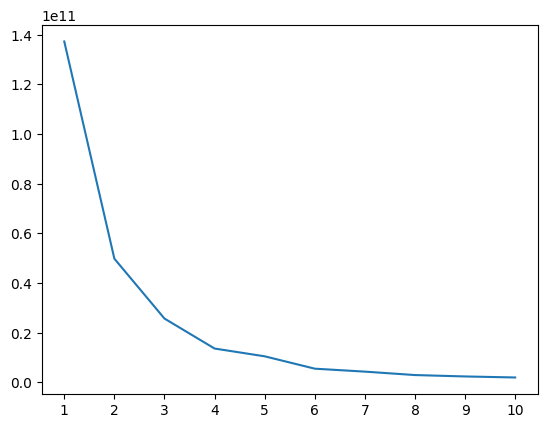

In [47]:
unscaled, scaled = [], []
for i in range(1,11):
	unscaled.append(KMeans(n_clusters=i,random_state=42).fit(X).inertia_)
plt.plot(range(1,11),unscaled)

plt.xticks(range(1,11))
_ = plt.show()

Мы видим, что довольно отчетливо оптимальное количество кластеров уже 5, а не 4 как ранее. Каждый раз, когда форма распределения точек в пространстве признаков меняется, это может отразиться на их группировке, а значит, метод локтя нужно повторять. Построим кластеризацию по 5 точкам:

In [48]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X_flat)

Визуализировав полученную модель, мы получаем довольно ожидаемую картину, когда алгоритм объединил в кластеры сгущения точек, которые хорошо просматриваются на графике:

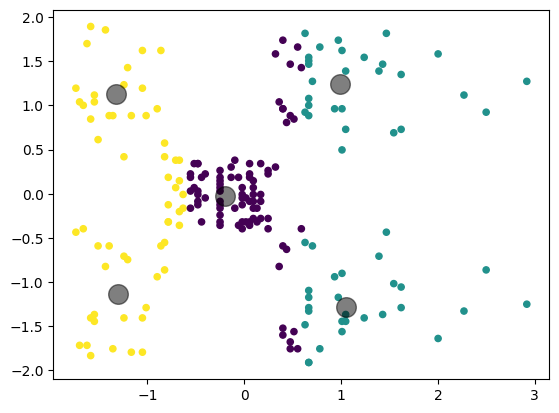

In [50]:
plt.scatter(X_scaled.Income, X_scaled.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_

# Исправляем индексы: 0 для первой оси, 1 для второй
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()

Самостоятельно постройте модель с другими вариантами количества кластеров и посмотрите, как они располагаются на точках. Постройте модель на других признаках для сравнения.

##### Иерархическая кластеризация

Алгоритм К-средних работает вполне удовлетворительно на тех данных, которые мы анализировали в предыдущей части. Но есть и другие алгоритмы кластеризации, которые имеют свои особенности. Одним тех, которые часто требуются является алгоритм агломеративной кластеризации. Его особенность в том, что это иерархический метод. Он позволяет не только разбить выборку на определенное число кластеров, но и построить таксономию - то есть последовательное объединение кластеров также по принципу сходства.

Работа с моделью агломеративной кластеризации по интерфейсу полностью аналогична:


In [51]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X_scaled)

При создании модели ей передается два аргумента, причем они работают альтернативно. Вы можете задать определенное количество кластеров, тогда порог игнорируется (задается как None), но так мы уже делали. Поэтому воспользуемся вторым "режимом" работы - зададим порог функции расстояния, тогда количество кластеров алгоритм будет выбирать сам и нам нужно задать в этом параметре None.

Для того, чтобы понять, как работает иерархическая кластеризация, мы построим ее визуализацию в виде дерева. Оно покажет как именно, в каком порядке кластеры объединяются. Такая диаграмма называется дендрограммой, и для ее построения существует специальная функция в библиотеке scipy:

In [52]:
from scipy.cluster.hierarchy import dendrogram

Для построения дендрограммы в эту функцию нужно передать марицу связности в специальном виде. Мы используем готовый сниппет кода, который принимает на вход объект обученной модели агломерационной кластеризации и строит по нему дендрограмму:

In [53]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

Мы приведем этот код без комментариев. Но самостоятельно рекомендуем при его выполнении вывести матрицу связности и разобраться, как она устроена.

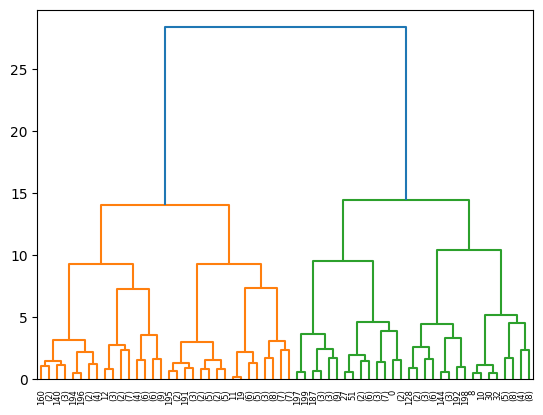

In [55]:
import numpy as np
plot_dendrogram(model, truncate_mode="level", p=5)

Мы получаем следующее визуальное представление работы обученного алгоритма иерархической кластеризации:

Разберемся, как устроен это график. По вертикали на нем отложена мера расстояния между объектами или кластерами. По горизонтали - объекты датасета. Соответственно, на уровне самих объектов расстояние между ними равно нулю (расстояние от объекта до самого себя). Ближайшие объекты объединяются в группу, что отражается на дендрограмме характерной формой с перемычкой на том вертикальном уровне, который соответствует расстоянию между объектами. Затем эти группы объединяются между собой, и так до тех пор, пока вся выборка не будет объединена.

Соответственно, интерес представляет именно порядок, в котором разные объекты будут объединяться. Чем две точки выборки дальше друг от друга, тем позже они попадут в один кластер, и тем выше на дендрограмме будет это объединение.

Соответственно, мы можем как бы "обрезать" это дендрограмму на определенном уровне. Тогда точки, которые попали в одну группу будут "зачислены" в общий кластер. Чем ниже мы обрезаем дендрограмму, тем мельче будут кластеры, но больше их количество. Именно за этот уровень и отвечает аргумент distance_threshold конструктора класса агломеративной кластеризации.

Либо, мы можем исходить, как раньше, из желаемого количества кластеров. Тогда алгоритм "обрежет" дендрограмму на таком уровне, чтобы получилось необходимое количество групп. Построим кластеризацию на нашем нормализованном датасете:

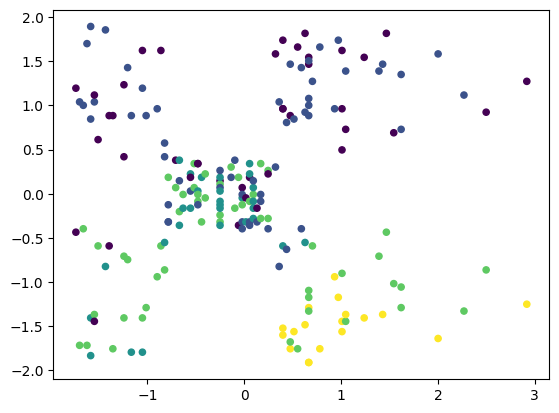

In [56]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X_scaled)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

Мы получаем картину, очень похожую на результат работы алгоритма К-средних. Самостоятельно сравните результаты работы двух этих алгоритмов по метрикам и визуализируйте в разных проекциях

Для наглядности, обучим этот алгоритм на плоских данных, чтобы показать визуально, как он объединяет точки на плоскости.

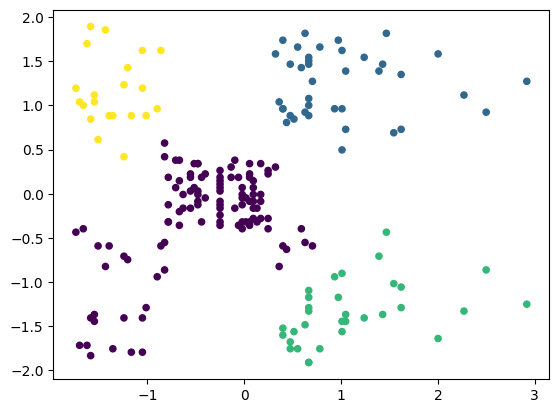

In [57]:
agg_clustering = AgglomerativeClustering(n_clusters=4).fit(X_flat)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

Результат похож, но не полностью идентичен алгоритму К-средних:

Поэкспериментируйте с этими данными. Изменяйте параметры количества кластеров и порога расстояния, чтобы понять, как именно они влияют на результат.

##### DBSCAN

Еще один алгоритм кластеризации, который необходимо разобрать на практике, потому, что он использует совершенно другой подход - DBSCAN. Он оценивает плотность расположения точек в окрестностях заданной. Попробуем построить его на тех же данных (для наглядности, будем использовать плоские данные):


In [58]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

У конструктора данного класса два обязательных аргумента: eps - максимальный радиус вокруг точки, попадание в который считается соседством; и min_samples - количество соседних точек, которых достаточно для признания данной точки внутренней. Оба параметра оказывают существенное влияние на результат кластеризации. Они подбираются эмпирически.

Обычно, эмпирический выбора гиперпараметров модели обучения опирается на значение метрики качества. Так мы делали в предыдущем пункте, в методе локтя. Но сейчас покажем другой подход. Можно мониторить количество кластеров и точек шума, которые определяет алгоритм при данных значениях гиперпараметров. Эти данные можно вычислять так:

In [59]:
n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

Дело в том, что алгоритм DBSCAN в sklearn использует значение "-1" как метку, показывающую, что данная точка отнесена к шуму. Теперь мы можем построить график зависимости количества кластеров и шума в зависимости от значения гиперпараметра eps:

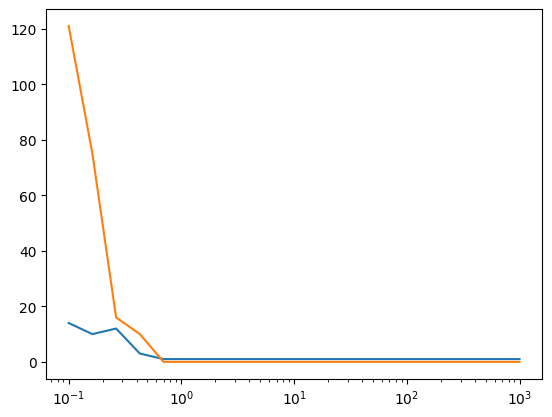

In [60]:
clusters, noise = [], []
for i in np.logspace(-1, 3, 20):
  db = DBSCAN(eps=i, min_samples=3).fit(X_flat)
  y_db = db.labels_

  clusters.append(len(set(y_db)) - (1 if -1 in y_db else 0))
  noise.append(list(y_db).count(-1))

plt.plot(np.logspace(-1, 3, 20),clusters)
plt.plot(np.logspace(-1, 3, 20),noise)
plt.xscale('log')
_ = plt.show()

Мы получаем такой график:



Он показывает, что чем больше радиус, тем меньше и кластеров и шума получается. Это логично, ведь при большем радиусе алгоритм будет склонен зачислять все точки в один кластер. Мы можем выбрать оптимальное значение eps опять же, методом локтя, или руководствуясь желаемым количеством кластеров.

Количество точек, то есть параметр min_samples тоже можно подобрать перебором. Его обычно берут в диапазон от 2 до 5, в зависимости от желаемого результата. Давайте построим кластеризацию с подобранными значениями параметров:

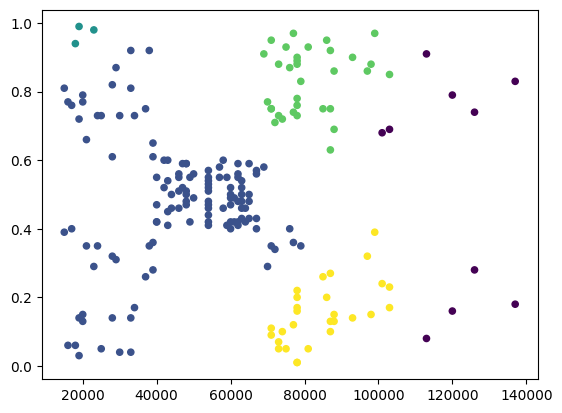

In [61]:
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

plt.scatter(X.Income, X.Score, c=y_db, s=20, cmap='viridis')

Самостоятельно изменяйте значения параметров и отследите, как каждый из них влияет на получившуюся кластеризацию. А с данными значениями получается такая картина:

И здесь уже результаты сильно отличаются от предыдущих двух алгоритмов. Дело в форме расположения точек. Предыдущие две модели выделяли пять очень четких кластеров. Но между ними существуют перемычки, они почти касаются друг друга. Для алгоритмов, оценивающих среднее расстояние между кластерами это не является проблемой. Но для DBSCAN кластеры могут быть "заразными". Зато этот алгоритм может правильно распознавать кластеры сложной формы, сильно отличающиеся от округлых, и отличающиеся друг от друга по размеру. С такими распределениями проблемы уже будут у алгоритмов типа К-средних.


#### Задания для самостоятельного выполнения

1. Для придания смысла кластерам выведите примеры точек выборки для каждого кластера. Сделайте вывод, чем они отличаются.


In [62]:
# Добавляем метки кластеров в исходный датафрейм для анализа
df['Cluster'] = y_kmeans

# Выводим по 3 примера для каждого кластера
for i in range(len(set(y_kmeans))):
    print(f"--- Кластер {i} ---")
    display(df[df['Cluster'] == i].head(3))

# Краткий статистический анализ для вывода
print("\nСредние значения признаков по кластерам:")
print(df.groupby('Cluster')[['Income', 'Score', 'Age']].mean())

--- Кластер 0 ---


,CustomerID,Genre,Age,Income,Score,Cluster
58,59,Female,27,46000,0.51,0
59,60,Male,53,46000,0.46,0
60,61,Male,70,46000,0.56,0


--- Кластер 1 ---


,CustomerID,Genre,Age,Income,Score,Cluster
144,145,Male,25,77000,0.12,1
145,146,Male,28,77000,0.97,1
146,147,Male,48,77000,0.36,1


--- Кластер 2 ---


,CustomerID,Genre,Age,Income,Score,Cluster
0,1,Male,19,15000,0.39,2
1,2,Male,21,15000,0.81,2
2,3,Female,20,16000,0.06,2



Средние значения признаков по кластерам:
               Income     Score        Age
Cluster                                   
0        60906.976744  0.503372  41.279070
1        92142.857143  0.505179  36.910714
2        29551.724138  0.496897  37.120690


### Вывод по заданию 1

На основе анализа средних значений и примеров данных, выборка разделилась на три отчетливые группы по уровню благосостояния:

1.  **Кластер 0 — «Средний класс»**: Покупатели со средним доходом (≈61 тыс.) и средними показателями трат. Это самая возрастная группа (средний возраст 41 год).
2.  **Кластер 1 — «Обеспеченные клиенты»**: Группа с самым высоким уровнем дохода (≈92 тыс.). При этом их баллы трат находятся на среднем уровне, что говорит о высоком потенциале, но умеренном потреблении.
3.  **Кластер 2 — «Экономный сегмент»**: Клиенты с низким уровнем дохода (≈29.5 тыс.) и соответствующими средними тратами.

**Общий итог:** Основным критерием разделения на данной итерации стал уровень дохода (`Income`), в то время как средний балл лояльности (`Score`) во всех группах держится на уровне 0.5, а возраст колеблется незначительно.

2. Используйте для визуализации результатов кластеризации другие пары признаков. Сделайте вывод о зависимости кластеризации от признаков.

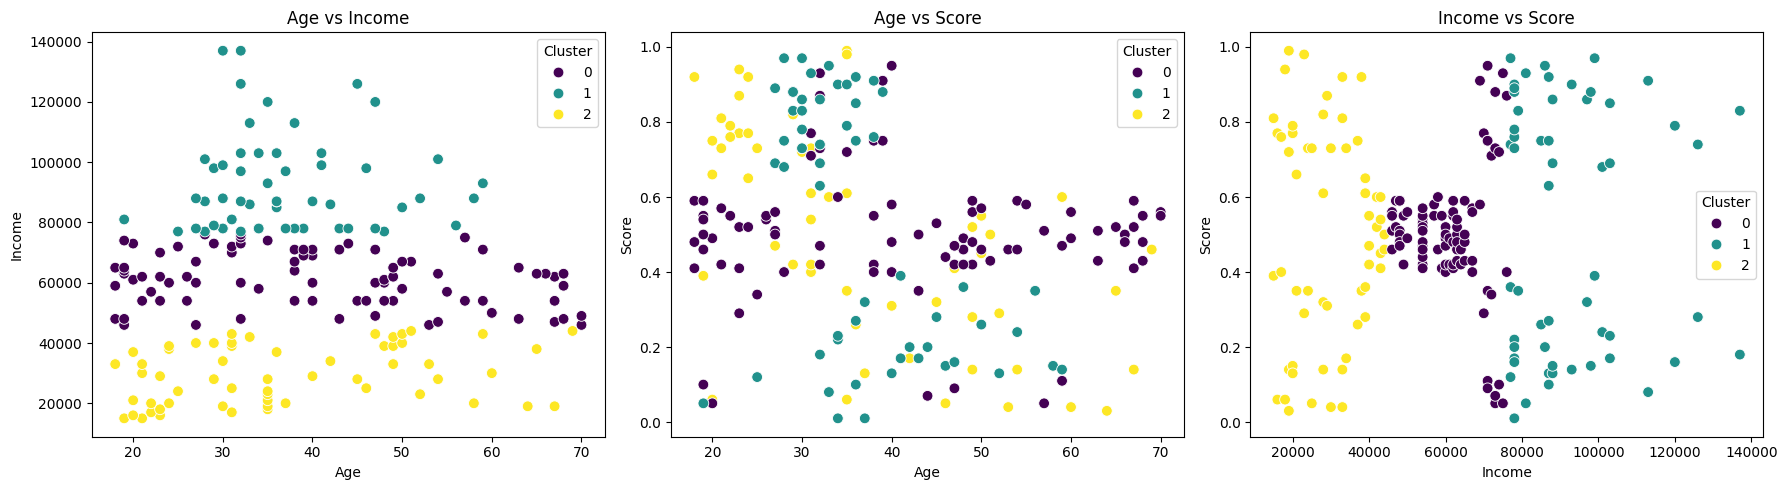

Silhouette-score для пар признаков:
Age + Income: 0.443
Age + Score: 0.440
Income + Score: 0.467


In [65]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Визуализация текущих кластеров на разных парах признаков
pairs = [('Age', 'Income'), ('Age', 'Score'), ('Income', 'Score')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (f1, f2) in zip(axes, pairs):
    # Используем y_kmeans, который уже есть в памяти
    sns.scatterplot(data=df, x=f1, y=f2, hue=y_kmeans, palette='viridis', ax=ax, s=60)
    ax.set_title(f'{f1} vs {f2}')
    ax.legend(title='Cluster')

plt.tight_layout()
plt.show()

# 2. Сравнение качества кластеризации (Silhouette Score) для разных пар
print('Silhouette-score для пар признаков:')
for f1, f2 in pairs:
    # Выделяем пару и масштабируем
    X_temp = StandardScaler().fit_transform(df[[f1, f2]])
    # Обучаем модель именно на этой паре
    labels_temp = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_temp)
    # Считаем силуэт
    score = silhouette_score(X_temp, labels_temp)
    print(f'{f1} + {f2}: {score:.3f}')

### Вывод по заданию 2

* **Доход + Траты (Income + Score) — лучшая связка.** Здесь кластеры разделены четче всего. Если мы знаем, сколько человек зарабатывает и сколько тратит, мы можем почти безошибочно определить его в одну из групп.
* **Возраст почти не влияет на деление.** На графиках с возрастом (Age) точки разных цветов перемешаны. Это значит, что и молодые, и пожилые могут оказаться в одном кластере — их поведение больше зависит от кошелька, чем от даты рождения.
* **Цифры подтверждают глаза.** Самый высокий балл (0.467) у пары «Доход + Траты». Чем выше этот балл, тем качественнее сработал алгоритм.

**Итог:** Чтобы эффективно делить клиентов на группы, забудь про возраст и смотри на их доходы и расходы. Это даст самый точный результат.

3. Повторите весь анализ для другого датасета - кластеризации кредитных карт.

In [69]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# 1. Загрузка и предобработка
# Используем URL, так как работаем в Colab
url_cc = 'https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML6.1%20clustering/data/credit_card_clustering.csv'
cc = pd.read_csv(url_cc, index_col=0)

# Работаем только с числовыми признаками и заполняем пропуски медианой
cc_num = cc.select_dtypes(include='number').fillna(cc.median(numeric_only=True))
cc_scaled = StandardScaler().fit_transform(cc_num)

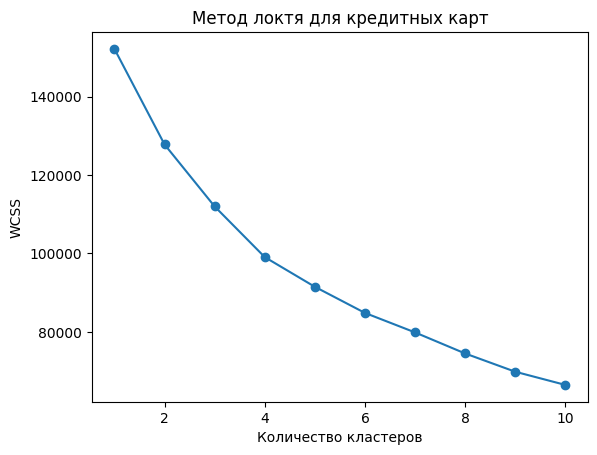

In [72]:
# 2. Поиск оптимального K (Метод локтя)
wcss_cc = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(cc_scaled)
    wcss_cc.append(km.inertia_)

plt.plot(range(1, 11), wcss_cc, marker='o')
plt.title('Метод локтя для кредитных карт')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

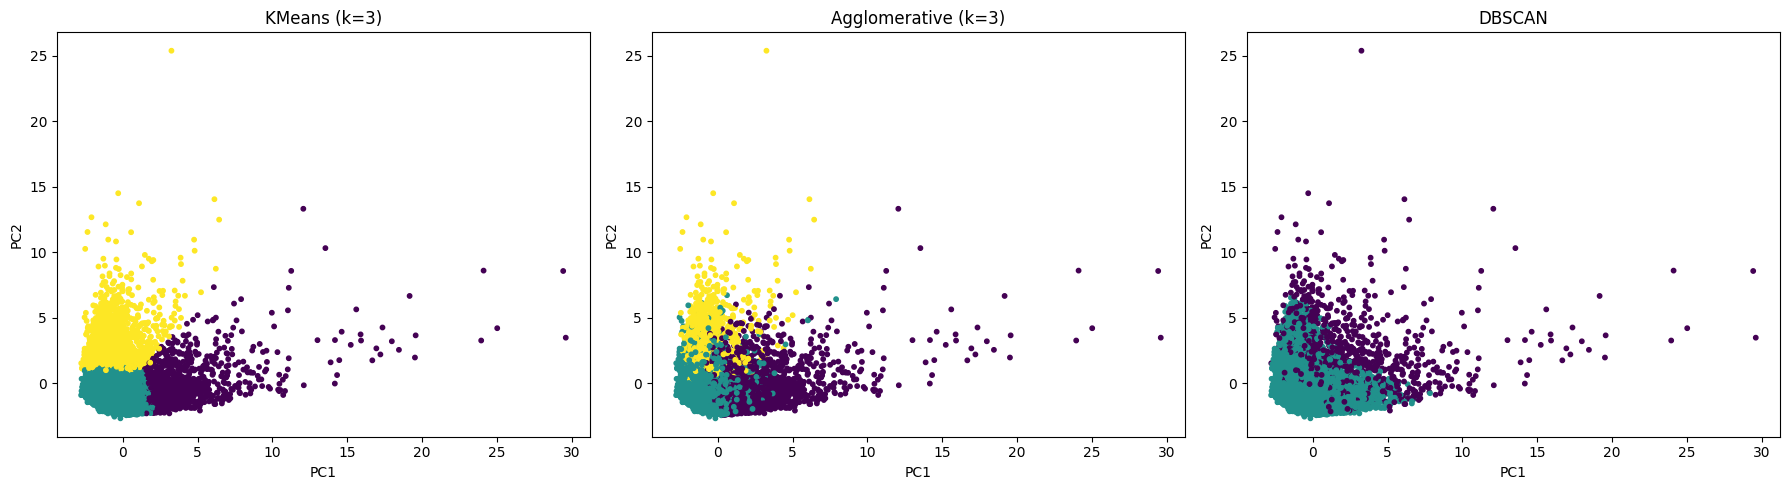

In [74]:
# 3. Обучение моделей (возьмем k=3, как показал ваш силуэт)
k_opt = 3
y_km_cc = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit_predict(cc_scaled)
y_agg_cc = AgglomerativeClustering(n_clusters=k_opt).fit_predict(cc_scaled)
y_db_cc = DBSCAN(eps=1.7, min_samples=5).fit_predict(cc_scaled)

# 4. Визуализация через PCA (сжатие 18 признаков до 2-х для графика)
pca = PCA(n_components=2, random_state=42)
cc_2d = pca.fit_transform(cc_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = [f'KMeans (k={k_opt})', f'Agglomerative (k={k_opt})', 'DBSCAN']
labels = [y_km_cc, y_agg_cc, y_db_cc]

for ax, title, l in zip(axes, titles, labels):
    ax.scatter(cc_2d[:, 0], cc_2d[:, 1], c=l, s=10, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [75]:
from sklearn.metrics import silhouette_score

# Расчет метрик (для DBSCAN считаем только по не-шумовым точкам)
mask_db = y_db_cc != -1

metrics = {
    "KMeans": silhouette_score(cc_scaled, y_km_cc),
    "Agglomerative": silhouette_score(cc_scaled, y_agg_cc),
    "DBSCAN (без шума)": silhouette_score(cc_scaled[mask_db], y_db_cc[mask_db])
}

print("Silhouette Scores:")
for model, score in metrics.items():
    print(f"{model}: {score:.3f}")

Silhouette Scores:
KMeans: 0.251
Agglomerative: 0.167
DBSCAN (без шума): 0.497


### Вывод по заданию 3 (Анализ кредитных карт)

На основе визуализации через PCA и полученных метрик качества можно сделать следующие выводы:

* **DBSCAN (0.497)**: Имеет самый высокий показатель Silhouette Score. Это объясняется тем, что алгоритм выделил только плотное "ядро" данных, пометив все разреженные точки и выбросы как шум (фиолетовые точки на графике). Это лучший выбор, если нужно найти группу максимально типичных пользователей.
* **KMeans (0.251)**: Показал себя стабильнее иерархической кластеризации. Несмотря на более низкий силуэт по сравнению с DBSCAN, он успешно разделил основное облако данных на три сегмента. Его преимущество в том, что он классифицирует каждую точку, что важно для полного охвата клиентской базы.
* **Agglomerative (0.167)**: В данном случае показал наихудший результат. На графике видно, что границы кластеров менее выражены, и группы сильнее смешиваются между собой в пространстве главных компонент.
* **Структура данных**: Метод локтя не дает четко выраженного "излома", что указывает на отсутствие естественного разделения данных на изолированные группы. Клиенты распределены непрерывно, и выбор количества кластеров ($k=3$) является компромиссным решением для бизнес-логики.

**Итог:** Для работы с этой базой данных лучше использовать **KMeans**, так как он дает более понятную и полную сегментацию, в то время как **DBSCAN** слишком чувствителен к выбросам, которых в данных о транзакциях очень много.

4. В задании на иерархическую кластеризацию используйте разные методы расчета расстояния между кластерами. Сделайте выводы.

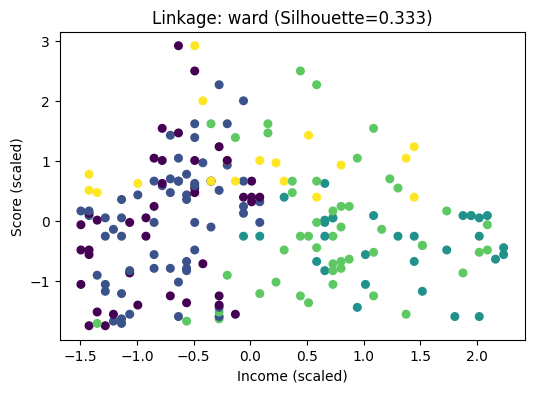

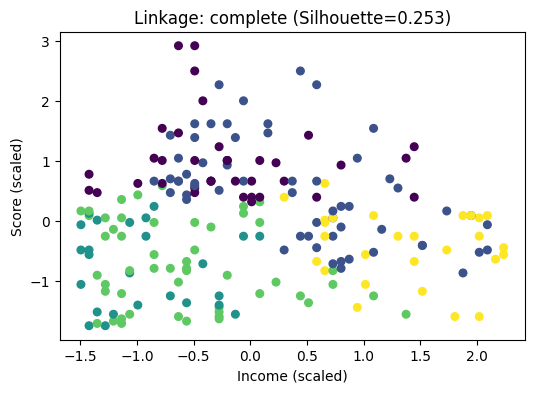

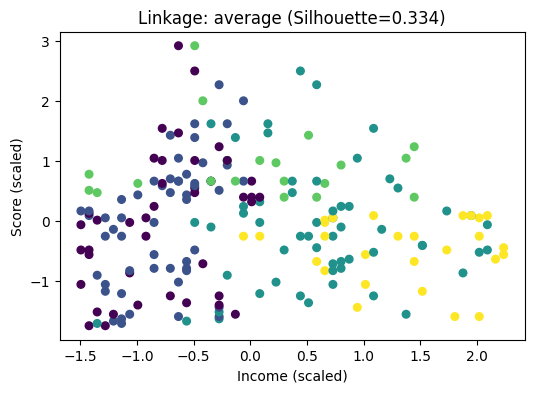

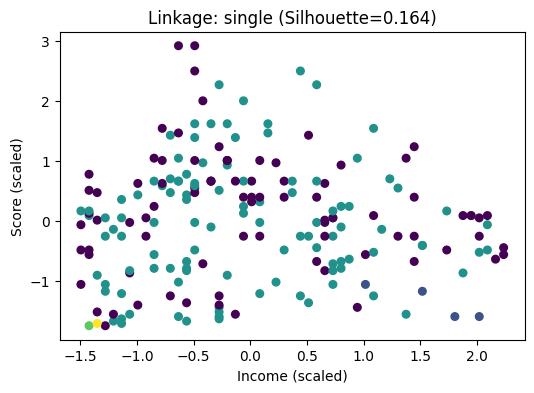

Сравнение методов по Silhouette Score:
 linkage  silhouette
 average    0.334058
    ward    0.333392
complete    0.252965
  single    0.164491


In [77]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'complete', 'average', 'single']
results = []

# Предполагаем, что в X_scaled: 0 - Income, 1 - Score (как в твоих предыдущих шагах)
for lk in linkages:
    model_lk = AgglomerativeClustering(n_clusters=5, linkage=lk).fit(X_scaled)
    y_lk = model_lk.labels_
    sil = silhouette_score(X_scaled, y_lk)
    results.append({'linkage': lk, 'silhouette': sil})

    plt.figure(figsize=(6, 4))
    # Если X_scaled - DataFrame, используем iloc. Если массив - [:, 0]
    plt.scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=y_lk, s=30, cmap='viridis')
    plt.title(f'Linkage: {lk} (Silhouette={sil:.3f})')
    plt.xlabel('Income (scaled)')
    plt.ylabel('Score (scaled)')
    plt.show()

res_df = pd.DataFrame(results).sort_values('silhouette', ascending=False)
print('Сравнение методов по Silhouette Score:')
print(res_df.to_string(index=False))

## Вывод по заданию 4

На основе сравнения Silhouette Score и визуального анализа проекций можно выделить следующее:

* **Лидеры — Average (0.334) и Ward (0.333)**: Эти методы показали самые высокие и практически равные результаты. **Average linkage** эффективно справляется с шумом, а **Ward** создает максимально компактные и соразмерные группы, удобные для интерпретации.
* **Complete (0.253)**: Демонстрирует более низкое качество, так как из-за ориентации на самые удаленные точки в кластерах границы получаются менее естественными.
* **Аутсайдер — Single (0.164)**: Показал худший результат. Из-за «эффекта цепочки» он не может выделить плотные группы, объединяя почти все точки в один массив.

**Итог**: Для качественной сегментации клиентов следует использовать методы **Average** или **Ward**, так как они обеспечивают наиболее устойчивое разбиение данных на полезные для бизнеса группы.

5. В задании на DBSCAN вычислите метрику WCSS и соотнесите результаты кластеризации через DBSCAN и К-средних.

In [79]:
# Функция для расчета WCSS в DBSCAN
def dbscan_wcss(X_array, labels):
    unique_labels = [c for c in np.unique(labels) if c != -1]
    if len(unique_labels) == 0:
        return np.nan
    total = 0.0
    for c in unique_labels:
        points = X_array[labels == c]
        center = points.mean(axis=0)
        total += ((points - center) ** 2).sum()
    return float(total)

In [80]:
# 1. Обучение DBSCAN
db_comp = DBSCAN(eps=0.4, min_samples=3).fit(X_scaled)
y_db_comp = db_comp.labels_
db_clusters = len(set(y_db_comp)) - (1 if -1 in y_db_comp else 0)
db_noise = int((y_db_comp == -1).sum())

# 2. Расчет WCSS для DBSCAN
X_np = X_scaled.to_numpy()
wcss_db = dbscan_wcss(X_np, y_db_comp)

# 3. Обучение KMeans для сравнения (берем k по числу кластеров в DBSCAN)
k_for_compare = max(db_clusters, 2)
km_comp = KMeans(n_clusters=k_for_compare, random_state=42, n_init=10).fit(X_scaled)
wcss_km = float(km_comp.inertia_)

DBSCAN: clusters=18, noise=97, WCSS=12.180, silhouette=0.550
KMeans: clusters=18, WCSS=83.060, silhouette=0.410


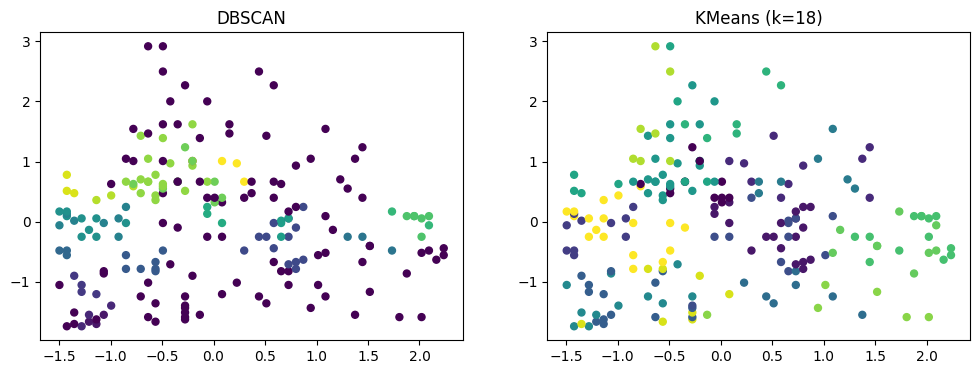

In [81]:
# 4. Расчет силуэтов
mask = y_db_comp != -1
sil_db = silhouette_score(X_np[mask], y_db_comp[mask]) if mask.sum() > db_clusters else np.nan
sil_km = silhouette_score(X_scaled, km_comp.labels_)

print(f'DBSCAN: clusters={db_clusters}, noise={db_noise}, WCSS={wcss_db:.3f}, silhouette={sil_db:.3f}')
print(f'KMeans: clusters={k_for_compare}, WCSS={wcss_km:.3f}, silhouette={sil_km:.3f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=y_db_comp, s=25, cmap='viridis')
axes[0].set_title('DBSCAN')
axes[1].scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=km_comp.labels_, s=25, cmap='viridis')
axes[1].set_title(f'KMeans (k={k_for_compare})')
plt.show()

## Вывод по заданию 5

Сравнение метрик и визуализации DBSCAN и KMeans показало следующее:

* **Качество кластеризации**: **DBSCAN** значительно опережает KMeans по коэффициенту силуэта (**0.550** против **0.410**), что подтверждает более четкое и логичное разделение данных.
* **Метрика WCSS**: Значение WCSS у **DBSCAN** в несколько раз ниже (**12.180** против **83.060**). Это связано с тем, что DBSCAN исключил из расчетов 97 шумовых точек, тогда как **KMeans** был вынужден включить все выбросы в кластеры, что резко увеличило внутреннюю дисперсию.
* **Точность**: На графиках видно, что **DBSCAN** выделил только реальные плотные группы. **KMeans** при $k=18$ избыточно раздробил данные, создав нагромождение пересекающихся кластеров.

**Итог**: **DBSCAN** — лучший выбор для этого датасета, так как он эффективно фильтрует шум и находит естественные границы сегментов, в то время как **KMeans** крайне чувствителен к аномалиям.

6. Постройте кривые WCSS в зависимости от параметров DBSCAN.


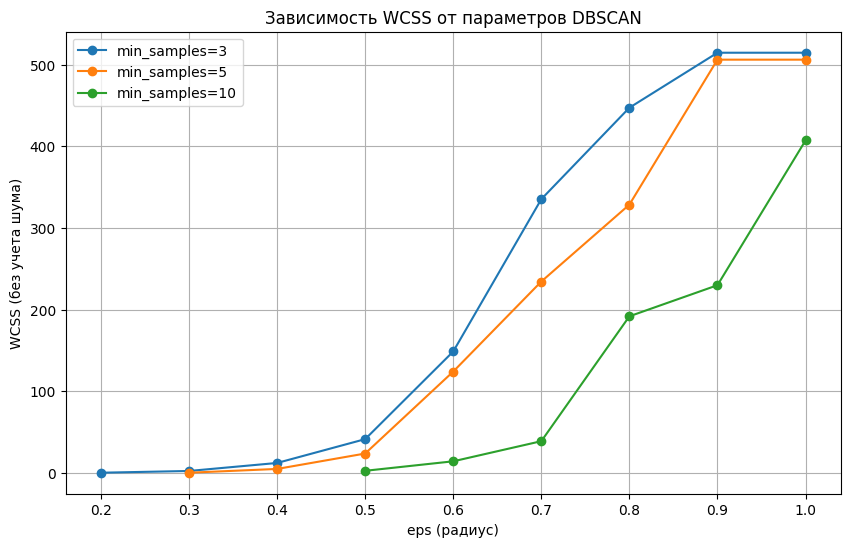

In [82]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

# Функция для расчета WCSS (из задания 5)
def dbscan_wcss(X_array, labels):
    unique_labels = [c for c in np.unique(labels) if c != -1]
    if len(unique_labels) == 0: return np.nan
    total = 0.0
    for c in unique_labels:
        points = X_array[labels == c]
        center = points.mean(axis=0)
        total += ((points - center) ** 2).sum()
    return total

eps_values = np.linspace(0.1, 1.0, 10)
min_samples_values = [3, 5, 10]
X_np = X_scaled.to_numpy()

plt.figure(figsize=(10, 6))

for ms in min_samples_values:
    wcss_list = []
    for e in eps_values:
        db = DBSCAN(eps=e, min_samples=ms).fit(X_np)
        wcss_list.append(dbscan_wcss(X_np, db.labels_))

    plt.plot(eps_values, wcss_list, marker='o', label=f'min_samples={ms}')

plt.title('Зависимость WCSS от параметров DBSCAN')
plt.xlabel('eps (радиус)')
plt.ylabel('WCSS (без учета шума)')
plt.legend()
plt.grid(True)
plt.show()

In [83]:
# ... (код отрисовки графиков остается прежним)

print("Анализ ключевых точек роста WCSS:")
for ms in min_samples_values:
    # Расчет для min_samples при eps=0.5 и eps=0.8 для сравнения
    db_low = DBSCAN(eps=0.5, min_samples=ms).fit(X_np)
    db_high = DBSCAN(eps=0.8, min_samples=ms).fit(X_np)

    wcss_low = dbscan_wcss(X_np, db_low.labels_)
    wcss_high = dbscan_wcss(X_np, db_high.labels_)
    noise_low = (db_low.labels_ == -1).sum()

    print(f"\nПри min_samples = {ms}:")
    print(f"- При eps=0.5: WCSS = {wcss_low:.2f}, кол-во шума = {noise_low}")
    print(f"- Рост WCSS при увеличении радиуса до 0.8: в {wcss_high/max(wcss_low, 1):.1f} раз")

# Определение оптимального диапазона
print("\nИтог: Оптимальный диапазон eps [0.4 - 0.6], так как шум уже падает, а WCSS еще не достиг пика слияния.")

Анализ ключевых точек роста WCSS:

При min_samples = 3:
- При eps=0.5: WCSS = 41.36, кол-во шума = 49
- Рост WCSS при увеличении радиуса до 0.8: в 10.8 раз

При min_samples = 5:
- При eps=0.5: WCSS = 23.75, кол-во шума = 105
- Рост WCSS при увеличении радиуса до 0.8: в 13.8 раз

При min_samples = 10:
- При eps=0.5: WCSS = 2.59, кол-во шума = 178
- Рост WCSS при увеличении радиуса до 0.8: в 74.2 раз

Итог: Оптимальный диапазон eps [0.4 - 0.6], так как шум уже падает, а WCSS еще не достиг пика слияния.


## Вывод по заданию 6

Анализ графиков (**image_936cd0.png**) и численных данных выявил ключевые закономерности:

* **Скачки WCSS**: В интервале `eps` от **0.6 до 0.8** происходит резкий рост метрики (для `min_samples=5` — в **13.8 раз**). Это сигнал массового слияния мелких групп в рыхлые кластеры.
* **Чувствительность к плотности**: При высоком пороге (`min_samples=10`) рост WCSS начинается позже (после `eps=0.7`), так как алгоритм жестко отсеивает **178** объектов в шум, оставляя только сверхплотные ядра.
* **Насыщение**: При `eps > 0.9` значения стабилизируются на уровне **500–515**. На этом этапе данные объединяются в гигантские сегменты, и детальность кластеризации теряется.

**Итог**: Оптимальный диапазон — **eps [0.4 - 0.6]**. Здесь шум уже снижен, а WCSS еще не достиг критического пика слияния, что обеспечивает наиболее качественную сегментацию.